In [2]:
# ============================================================
# STEP 1 — SETUP & REPRODUCIBILITY
# ============================================================

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_validate,
    GridSearchCV
)

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve,
    auc
)

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Libraries imported successfully.")
print("Random State:", RANDOM_STATE)

Libraries imported successfully.
Random State: 42


In [3]:
# ============================================================
# STEP 2 — PROJECT FORMULATION
# ============================================================

PROJECT_TITLE = "Heart Disease Prediction using Machine Learning"

PROBLEM_STATEMENT = """
The objective of this project is to develop a machine learning-based
classification system that can predict whether a patient has heart
disease based on clinical and physiological features.
"""

STAKEHOLDERS = [
    "Patients",
    "Healthcare Professionals",
    "Researchers",
    "Healthcare Decision-Support Systems"
]

OBJECTIVE = """
Build a reproducible binary classification pipeline to predict
the presence or absence of heart disease.
"""

SUCCESS_CRITERIA = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1-Score",
    "ROC-AUC",
    "Confusion Matrix"
]

TARGET_NAME = "target"

print("Project Title:", PROJECT_TITLE)
print("\nProblem Statement:")
print(PROBLEM_STATEMENT)

print("Stakeholders:")
for stakeholder in STAKEHOLDERS:
    print("-", stakeholder)

print("\nObjective:")
print(OBJECTIVE)

print("Success Criteria:")
for metric in SUCCESS_CRITERIA:
    print("-", metric)

Project Title: Heart Disease Prediction using Machine Learning

Problem Statement:

The objective of this project is to develop a machine learning-based
classification system that can predict whether a patient has heart
disease based on clinical and physiological features.

Stakeholders:
- Patients
- Healthcare Professionals
- Researchers
- Healthcare Decision-Support Systems

Objective:

Build a reproducible binary classification pipeline to predict
the presence or absence of heart disease.

Success Criteria:
- Accuracy
- Precision
- Recall
- F1-Score
- ROC-AUC
- Confusion Matrix


In [5]:
# ============================================================
# STEP 3 — DATASET LOADING & DATA PROVENANCE
# ============================================================

from google.colab import files

# Upload Dataset
uploaded = files.upload()

# Get file name
file_name = next(iter(uploaded))

# Load Dataset
df = pd.read_csv(file_name)

# Dataset Information
DATASET_NAME = "Heart Disease Dataset"
DATASET_SOURCE = "Kaggle"
DATASET_URL = "https://www.kaggle.com/datasets/eishkaran/heart-disease"

# Target Variable
TARGET = "target"

print("=" * 60)
print("DATASET INFORMATION")
print("=" * 60)

print("Dataset Name :", DATASET_NAME)
print("Source       :", DATASET_SOURCE)
print("Dataset URL  :", DATASET_URL)
print("File Name    :", file_name)
print("Dataset Shape:", df.shape)

print("\nFirst 5 Rows:")
display(df.head())

print("\nTarget Variable:", TARGET)

print("\nTarget Distribution:")
display(df[TARGET].value_counts().sort_index())

print("\nTarget Percentage:")
display(
    (df[TARGET].value_counts(normalize=True).sort_index() * 100)
    .round(2)
    .rename("Percentage")
)

Saving heart_statlog_cleveland_hungary_final.csv to heart_statlog_cleveland_hungary_final.csv
DATASET INFORMATION
Dataset Name : Heart Disease Dataset
Source       : Kaggle
Dataset URL  : https://www.kaggle.com/datasets/eishkaran/heart-disease
File Name    : heart_statlog_cleveland_hungary_final.csv
Dataset Shape: (1190, 12)

First 5 Rows:


,age,sex,chest pain type,resting bp s,cholesterol,fasting blood sugar,resting ecg,max heart rate,exercise angina,oldpeak,ST slope,target
0,40,1,2,140,289,0,0,172,0,0.0,1,0
1,49,0,3,160,180,0,0,156,0,1.0,2,1
2,37,1,2,130,283,0,1,98,0,0.0,1,0
3,48,0,4,138,214,0,0,108,1,1.5,2,1
4,54,1,3,150,195,0,0,122,0,0.0,1,0



Target Variable: target

Target Distribution:


,count
target,
0,561
1,629



Target Percentage:


,Percentage
target,
0,47.14
1,52.86


In [6]:
# ============================================================
# STEP 4 — DATA AUDIT
# ============================================================

print("=" * 60)
print("DATA AUDIT")
print("=" * 60)

# 1. Dataset Shape
print("\n1. Dataset Shape")
print("Rows    :", df.shape[0])
print("Columns :", df.shape[1])

# 2. Data Types
print("\n2. Data Types")
display(df.dtypes.to_frame("Data Type"))

# 3. Missing Values
print("\n3. Missing Values")
missing_summary = pd.DataFrame({
    "Missing Count": df.isnull().sum(),
    "Missing Percentage (%)": (df.isnull().mean() * 100).round(2)
})
display(missing_summary)

# 4. Duplicate Rows
print("\n4. Duplicate Rows")
duplicate_count = df.duplicated().sum()
duplicate_percentage = (duplicate_count / len(df)) * 100

print("Duplicate Rows       :", duplicate_count)
print("Duplicate Percentage :", round(duplicate_percentage, 2), "%")

# 5. Unique Values
print("\n5. Unique Values")
unique_summary = df.nunique().to_frame("Unique Values")
display(unique_summary)

# 6. Numerical Summary
print("\n6. Numerical Range Summary")
numerical_summary = df.describe().T[
    ["count", "mean", "std", "min", "max"]
].round(2)
display(numerical_summary)

# 7. Zero / Sentinel Value Audit
print("\n7. Zero / Sentinel Value Audit")

zero_summary = pd.DataFrame({
    "Zero Count": (df == 0).sum(),
    "Zero Percentage (%)": ((df == 0).mean() * 100).round(2)
})

display(zero_summary)

# 8. Value Counts for All Features
print("\n8. Value Counts")

for column in df.columns:
    print(f"\n--- {column} ---")
    display(df[column].value_counts().sort_index().to_frame("Count"))

# 9. Overall Audit Summary
print("\n" + "=" * 60)
print("AUDIT SUMMARY")
print("=" * 60)

print("Dataset Shape       :", df.shape)
print("Missing Values      :", df.isnull().sum().sum())
print("Duplicate Rows      :", duplicate_count)
print("Duplicate %         :", round(duplicate_percentage, 2), "%")
print("Target Column       :", TARGET)
print("Target Classes      :", df[TARGET].nunique())
print("=" * 60)

DATA AUDIT

1. Dataset Shape
Rows    : 1190
Columns : 12

2. Data Types


,Data Type
age,int64
sex,int64
chest pain type,int64
resting bp s,int64
cholesterol,int64
fasting blood sugar,int64
resting ecg,int64
max heart rate,int64
exercise angina,int64
oldpeak,float64



3. Missing Values


,Missing Count,Missing Percentage (%)
age,0,0.0
sex,0,0.0
chest pain type,0,0.0
resting bp s,0,0.0
cholesterol,0,0.0
fasting blood sugar,0,0.0
resting ecg,0,0.0
max heart rate,0,0.0
exercise angina,0,0.0
oldpeak,0,0.0



4. Duplicate Rows
Duplicate Rows       : 272
Duplicate Percentage : 22.86 %

5. Unique Values


...


--- ST slope ---


,Count
ST slope,
0,1
1,526
2,582
3,81



--- target ---


,Count
target,
0,561
1,629



AUDIT SUMMARY
Dataset Shape       : (1190, 12)
Missing Values      : 0
Duplicate Rows      : 272
Duplicate %         : 22.86 %
Target Column       : target
Target Classes      : 2


In [7]:
# ============================================================
# STEP 5 — DATA CLEANING
# ============================================================

# Remove exact duplicate rows
df_clean = df.drop_duplicates().copy()

# Replace invalid zero values with NaN
df_clean["resting bp s"] = df_clean["resting bp s"].replace(0, np.nan)
df_clean["cholesterol"] = df_clean["cholesterol"].replace(0, np.nan)

# Impute invalid/missing numerical values using median
df_clean["resting bp s"] = df_clean["resting bp s"].fillna(
    df_clean["resting bp s"].median()
)

df_clean["cholesterol"] = df_clean["cholesterol"].fillna(
    df_clean["cholesterol"].median()
)

# Final cleaning check
print("=" * 60)
print("DATA CLEANING SUMMARY")
print("=" * 60)

print("Original Shape :", df.shape)
print("Cleaned Shape  :", df_clean.shape)
print("Rows Removed   :", len(df) - len(df_clean))

print("\nMissing Values After Cleaning:")
display(df_clean.isnull().sum().to_frame("Missing Count"))

print("\nDuplicate Rows After Cleaning:",
      df_clean.duplicated().sum())

print("\nCleaned Target Distribution:")
display(df_clean[TARGET].value_counts().sort_index())

# Use cleaned dataset from this point onward
df = df_clean.copy()

print("\nFinal Dataset Shape:", df.shape)

DATA CLEANING SUMMARY
Original Shape : (1190, 12)
Cleaned Shape  : (918, 12)
Rows Removed   : 272

Missing Values After Cleaning:


,Missing Count
age,0
sex,0
chest pain type,0
resting bp s,0
cholesterol,0
fasting blood sugar,0
resting ecg,0
max heart rate,0
exercise angina,0
oldpeak,0



Duplicate Rows After Cleaning: 0

Cleaned Target Distribution:


,count
target,
0,410
1,508



Final Dataset Shape: (918, 12)


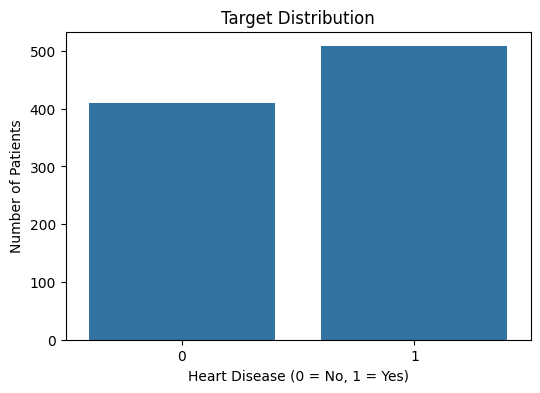

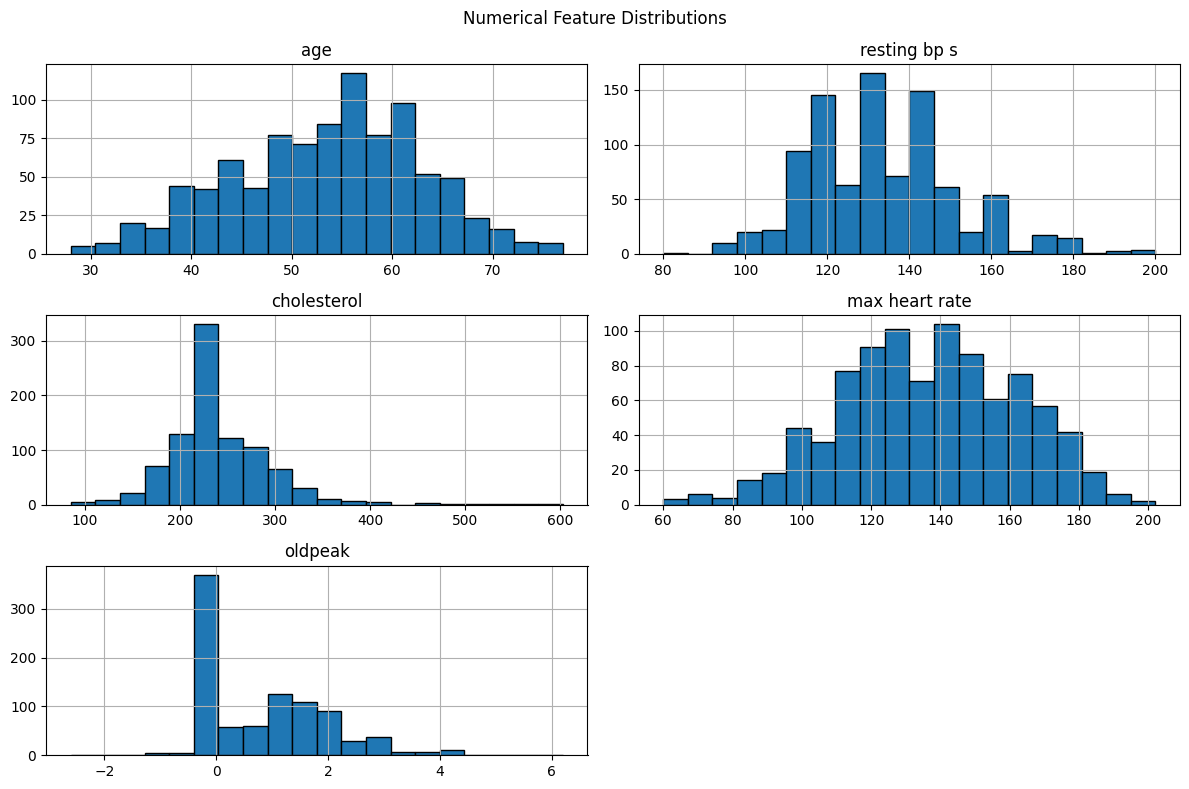

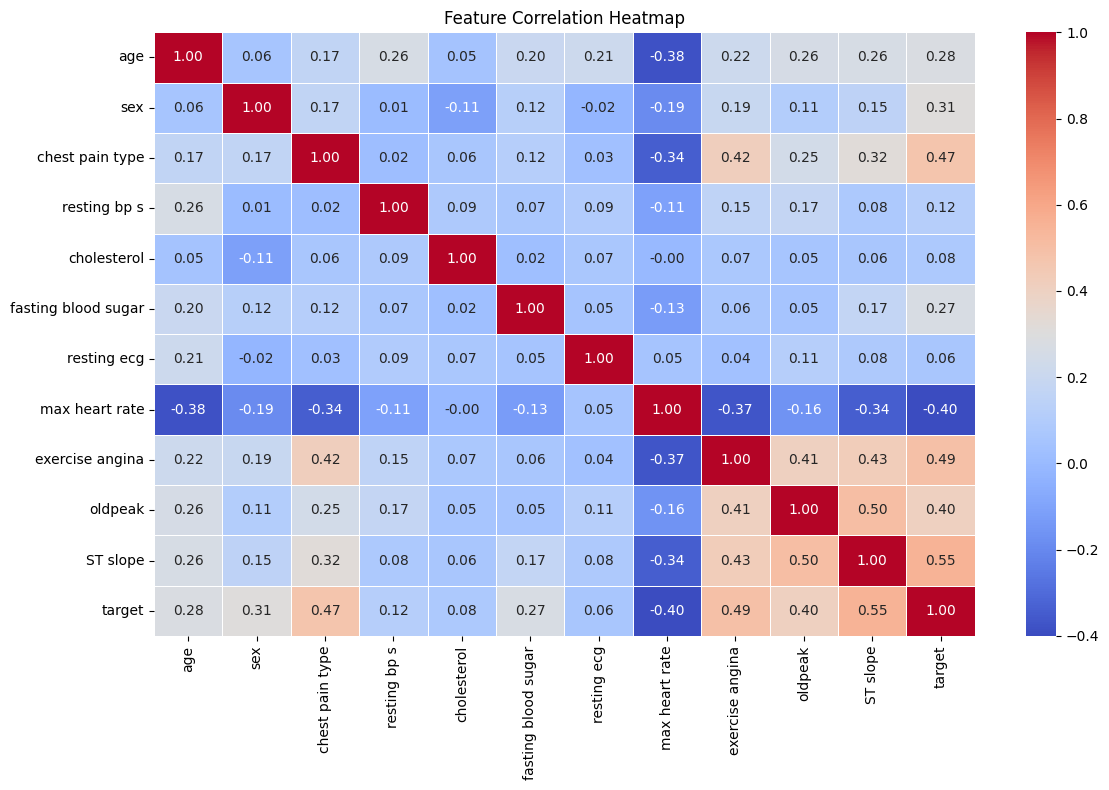

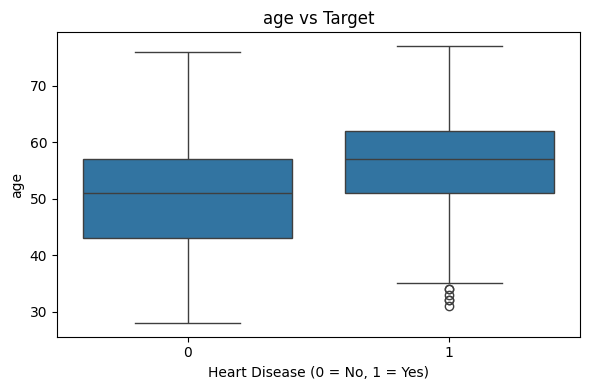

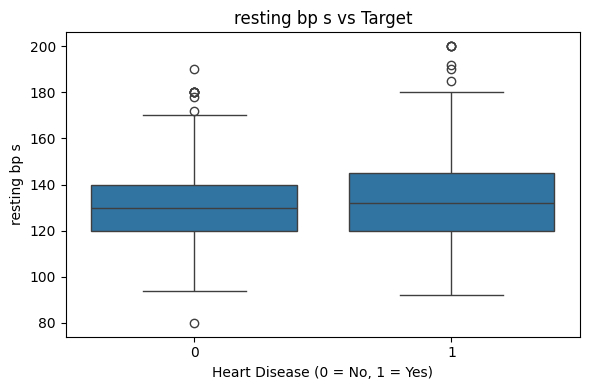

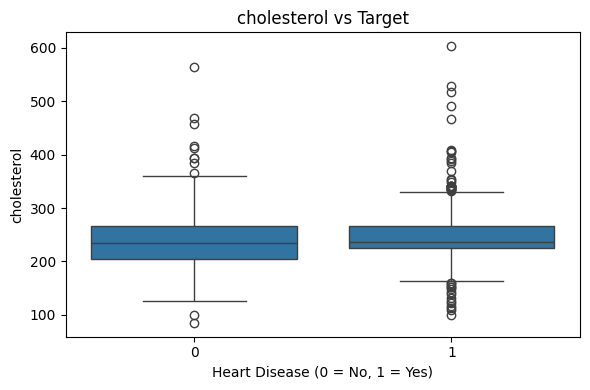

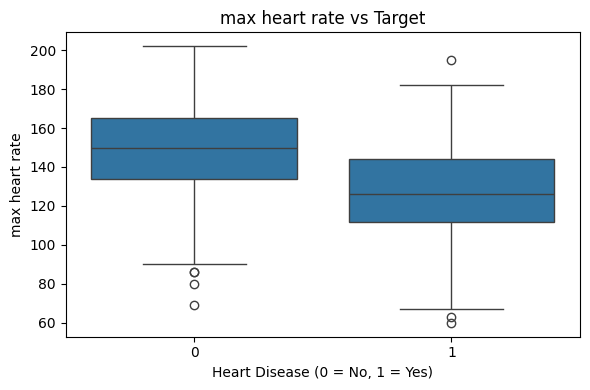

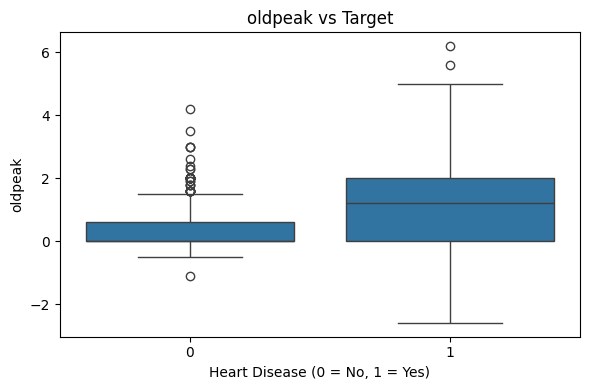

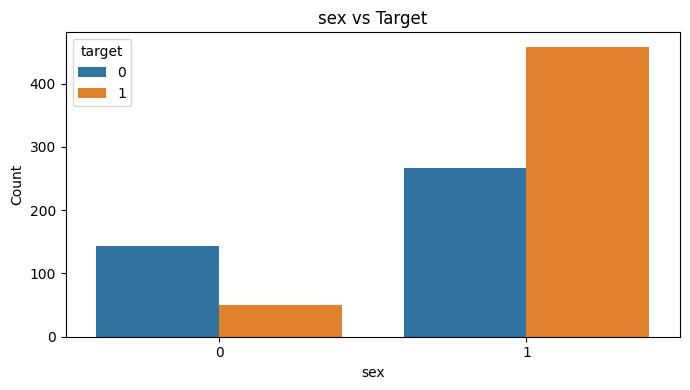

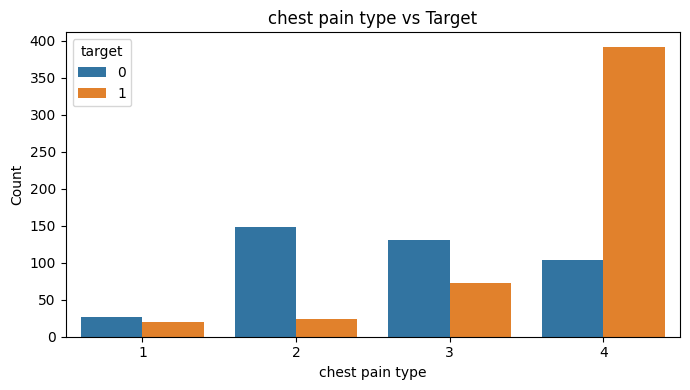

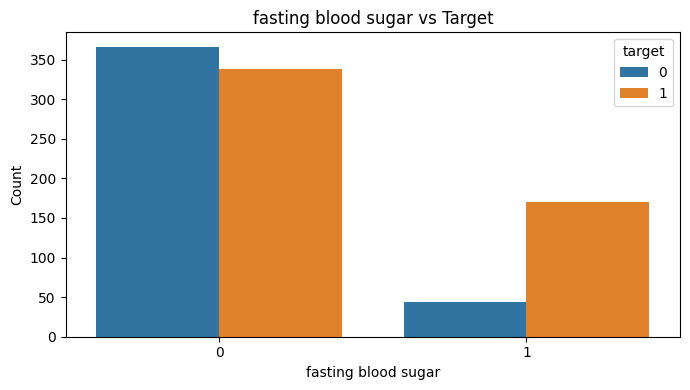

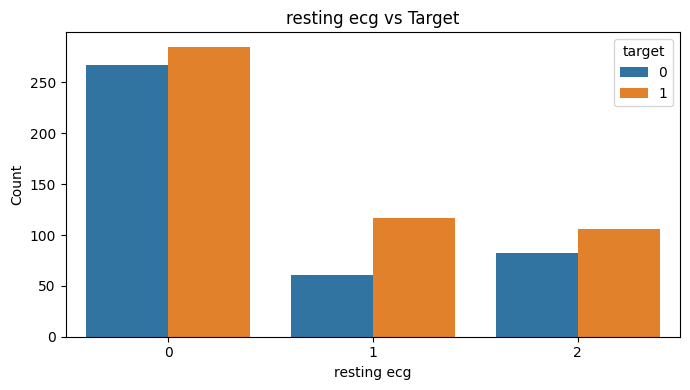

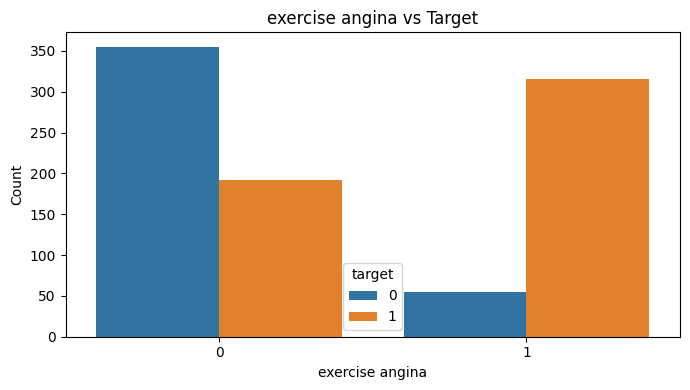

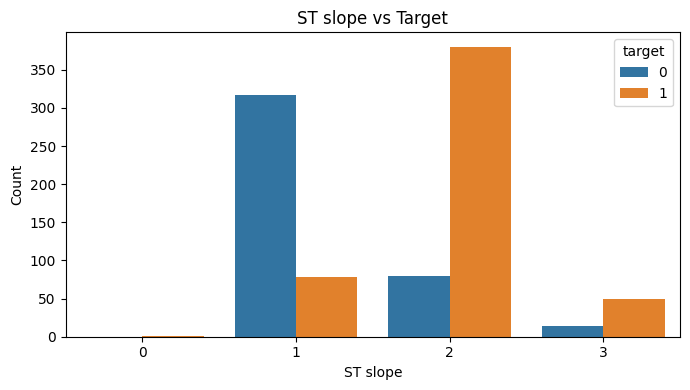

In [8]:
# ============================================================
# STEP 6 — EDA & VISUALIZATION
# ============================================================

# Target Distribution
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x=TARGET)
plt.title("Target Distribution")
plt.xlabel("Heart Disease (0 = No, 1 = Yes)")
plt.ylabel("Number of Patients")
plt.show()


# Numerical Feature Distributions
numerical_features = [
    "age",
    "resting bp s",
    "cholesterol",
    "max heart rate",
    "oldpeak"
]

df[numerical_features].hist(
    figsize=(12, 8),
    bins=20,
    edgecolor="black"
)

plt.suptitle("Numerical Feature Distributions")
plt.tight_layout()
plt.show()


# Feature Correlation Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()


# Numerical Features vs Target
for feature in numerical_features:
    plt.figure(figsize=(6, 4))
    sns.boxplot(data=df, x=TARGET, y=feature)
    plt.title(f"{feature} vs Target")
    plt.xlabel("Heart Disease (0 = No, 1 = Yes)")
    plt.ylabel(feature)
    plt.tight_layout()
    plt.show()


# Categorical Features vs Target
categorical_features = [
    "sex",
    "chest pain type",
    "fasting blood sugar",
    "resting ecg",
    "exercise angina",
    "ST slope"
]

for feature in categorical_features:
    plt.figure(figsize=(7, 4))
    sns.countplot(data=df, x=feature, hue=TARGET)
    plt.title(f"{feature} vs Target")
    plt.xlabel(feature)
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

In [9]:
# ============================================================
# STEP 7 — TRAIN / TEST SPLIT & LEAKAGE CONTROL
# ============================================================

# Separate Features and Target
X = df.drop(columns=[TARGET])
y = df[TARGET]

# Stratified 80/20 Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE
)

print("=" * 60)
print("TRAIN / TEST SPLIT")
print("=" * 60)

print("Original Dataset :", X.shape)
print("Training Set     :", X_train.shape)
print("Testing Set      :", X_test.shape)

print("\nTraining Target Distribution:")
display(y_train.value_counts().sort_index())

print("\nTesting Target Distribution:")
display(y_test.value_counts().sort_index())

print("\nTraining Target Percentage:")
display(
    (y_train.value_counts(normalize=True).sort_index() * 100)
    .round(2)
    .rename("Percentage (%)")
)

print("\nTesting Target Percentage:")
display(
    (y_test.value_counts(normalize=True).sort_index() * 100)
    .round(2)
    .rename("Percentage (%)")
)

print("\nRandom State:", RANDOM_STATE)
print("Split Strategy: Stratified 80/20")

TRAIN / TEST SPLIT
Original Dataset : (918, 11)
Training Set     : (734, 11)
Testing Set      : (184, 11)

Training Target Distribution:


,count
target,
0,328
1,406



Testing Target Distribution:


,count
target,
0,82
1,102



Training Target Percentage:


,Percentage (%)
target,
0,44.69
1,55.31



Testing Target Percentage:


,Percentage (%)
target,
0,44.57
1,55.43



Random State: 42
Split Strategy: Stratified 80/20


In [10]:
# ============================================================
# STEP 8 — PREPROCESSING
# ============================================================

# Identify feature types
categorical_features = [
    "sex",
    "chest pain type",
    "fasting blood sugar",
    "resting ecg",
    "exercise angina",
    "ST slope"
]

numerical_features = [
    "age",
    "resting bp s",
    "cholesterol",
    "max heart rate",
    "oldpeak"
]

# Create preprocessing pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numerical_features
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            categorical_features
        )
    ]
)

# Fit only on training data to prevent data leakage
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("=" * 60)
print("PREPROCESSING")
print("=" * 60)

print("Numerical Features  :", len(numerical_features))
print("Categorical Features:", len(categorical_features))

print("\nTraining Data Before Preprocessing :", X_train.shape)
print("Training Data After Preprocessing  :", X_train_processed.shape)

print("\nTesting Data Before Preprocessing  :", X_test.shape)
print("Testing Data After Preprocessing   :", X_test_processed.shape)

print("\nPreprocessing completed successfully.")
print("Scaler and Encoder fitted only on X_train.")

PREPROCESSING
Numerical Features  : 5
Categorical Features: 6

Training Data Before Preprocessing : (734, 11)
Training Data After Preprocessing  : (734, 22)

Testing Data Before Preprocessing  : (184, 11)
Testing Data After Preprocessing   : (184, 22)

Preprocessing completed successfully.
Scaler and Encoder fitted only on X_train.


In [11]:
# ============================================================
# STEP 9 — BASELINE MODEL
# ============================================================

from sklearn.dummy import DummyClassifier

baseline_model = DummyClassifier(
    strategy="most_frequent"
)

baseline_model.fit(X_train_processed, y_train)

y_pred_baseline = baseline_model.predict(X_test_processed)

baseline_accuracy = accuracy_score(y_test, y_pred_baseline)
baseline_precision = precision_score(
    y_test, y_pred_baseline, zero_division=0
)
baseline_recall = recall_score(
    y_test, y_pred_baseline, zero_division=0
)
baseline_f1 = f1_score(
    y_test, y_pred_baseline, zero_division=0
)

print("=" * 60)
print("BASELINE MODEL")
print("=" * 60)

print("Model: DummyClassifier (Most Frequent)")
print("Accuracy :", round(baseline_accuracy, 4))
print("Precision:", round(baseline_precision, 4))
print("Recall   :", round(baseline_recall, 4))
print("F1-Score :", round(baseline_f1, 4))

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred_baseline,
        zero_division=0
    )
)

BASELINE MODEL
Model: DummyClassifier (Most Frequent)
Accuracy : 0.5543
Precision: 0.5543
Recall   : 1.0
F1-Score : 0.7133

Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        82
           1       0.55      1.00      0.71       102

    accuracy                           0.55       184
   macro avg       0.28      0.50      0.36       184
weighted avg       0.31      0.55      0.40       184



In [12]:
# ============================================================
# STEP 10 — KNN MODEL
# ============================================================

from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(
    n_neighbors=5
)

knn_model.fit(X_train_processed, y_train)

y_pred_knn = knn_model.predict(X_test_processed)
y_prob_knn = knn_model.predict_proba(X_test_processed)[:, 1]

knn_accuracy = accuracy_score(y_test, y_pred_knn)
knn_precision = precision_score(y_test, y_pred_knn, zero_division=0)
knn_recall = recall_score(y_test, y_pred_knn, zero_division=0)
knn_f1 = f1_score(y_test, y_pred_knn, zero_division=0)
knn_auc = roc_auc_score(y_test, y_prob_knn)

print("=" * 60)
print("KNN MODEL")
print("=" * 60)

print("Number of Neighbors:", 5)
print("Accuracy :", round(knn_accuracy, 4))
print("Precision:", round(knn_precision, 4))
print("Recall   :", round(knn_recall, 4))
print("F1-Score :", round(knn_f1, 4))
print("ROC-AUC  :", round(knn_auc, 4))

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred_knn,
        zero_division=0
    )
)

KNN MODEL
Number of Neighbors: 5
Accuracy : 0.8804
Precision: 0.9
Recall   : 0.8824
F1-Score : 0.8911
ROC-AUC  : 0.9385

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.88      0.87        82
           1       0.90      0.88      0.89       102

    accuracy                           0.88       184
   macro avg       0.88      0.88      0.88       184
weighted avg       0.88      0.88      0.88       184



In [ ]:
!pip install -q "tabpfn==6.2.1"

In [36]:
# ============================================================
# TABPFN LICENSE SETUP
# ============================================================

import os

os.environ["TABPFN_TOKEN"] = "tabpfn_sk_s1axVRHwjsXHlS0s_oUvBINdaPQQSqOj68gtCVymgtw"

print("TabPFN API key configured.")

TabPFN API key configured.


In [39]:
# ============================================================
# STEP 11 — TABPFN MODEL
# ============================================================

from tabpfn import TabPFNClassifier

tabpfn_model = TabPFNClassifier(
    device="cpu"
)

tabpfn_model.fit(
    X_train_processed,
    y_train
)

y_pred_tabpfn = tabpfn_model.predict(
    X_test_processed
)

y_prob_tabpfn = tabpfn_model.predict_proba(
    X_test_processed
)[:, 1]

tabpfn_accuracy = accuracy_score(
    y_test,
    y_pred_tabpfn
)

tabpfn_precision = precision_score(
    y_test,
    y_pred_tabpfn,
    zero_division=0
)

tabpfn_recall = recall_score(
    y_test,
    y_pred_tabpfn,
    zero_division=0
)

tabpfn_f1 = f1_score(
    y_test,
    y_pred_tabpfn,
    zero_division=0
)

tabpfn_auc = roc_auc_score(
    y_test,
    y_prob_tabpfn
)

print("=" * 60)
print("TABPFN MODEL")
print("=" * 60)

print("Accuracy :", round(tabpfn_accuracy, 4))
print("Precision:", round(tabpfn_precision, 4))
print("Recall   :", round(tabpfn_recall, 4))
print("F1-Score :", round(tabpfn_f1, 4))
print("ROC-AUC  :", round(tabpfn_auc, 4))

print("\nClassification Report:")

print(
    classification_report(
        y_test,
        y_pred_tabpfn,
        zero_division=0
    )
)

TABPFN MODEL
Accuracy : 0.8967
Precision: 0.8952
Recall   : 0.9216
F1-Score : 0.9082
ROC-AUC  : 0.937

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.87      0.88        82
           1       0.90      0.92      0.91       102

    accuracy                           0.90       184
   macro avg       0.90      0.89      0.90       184
weighted avg       0.90      0.90      0.90       184



In [20]:
# ============================================================
# STEP 12 — TABICLv2 MODEL
# ============================================================

!pip -q install tabicl

from tabicl import TabICLClassifier

tabicl_model = TabICLClassifier(
    device="cpu",
    random_state=RANDOM_STATE
)

tabicl_model.fit(X_train_processed, y_train)

y_pred_tabicl = tabicl_model.predict(X_test_processed)
y_prob_tabicl = tabicl_model.predict_proba(X_test_processed)[:, 1]

tabicl_accuracy = accuracy_score(y_test, y_pred_tabicl)
tabicl_precision = precision_score(y_test, y_pred_tabicl, zero_division=0)
tabicl_recall = recall_score(y_test, y_pred_tabicl, zero_division=0)
tabicl_f1 = f1_score(y_test, y_pred_tabicl, zero_division=0)
tabicl_auc = roc_auc_score(y_test, y_prob_tabicl)

print("=" * 60)
print("TABICLv2 MODEL")
print("=" * 60)

print("Accuracy :", round(tabicl_accuracy, 4))
print("Precision:", round(tabicl_precision, 4))
print("Recall   :", round(tabicl_recall, 4))
print("F1-Score :", round(tabicl_f1, 4))
print("ROC-AUC  :", round(tabicl_auc, 4))

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred_tabicl,
        zero_division=0
    )
)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 310.4/310.4 kB 12.0 MB/s eta 0:00:00
INFO: You are downloading 'tabicl-classifier-v2-20260212.ckpt', the latest best-performing version, used in our TabICLv2 paper.

Checkpoint 'tabicl-classifier-v2-20260212.ckpt' not cached.



tabicl-classifier-v2-20260212.ckpt: reconstructing file:   0%|          |  0.00B /  110MB            

tabicl-classifier-v2-20260212.ckpt: downloading bytes:           |  0.00B            

TABICLv2 MODEL
Accuracy : 0.8967
Precision: 0.8807
Recall   : 0.9412
F1-Score : 0.91
ROC-AUC  : 0.9341

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.84      0.88        82
           1       0.88      0.94      0.91       102

    accuracy                           0.90       184
   macro avg       0.90      0.89      0.89       184
weighted avg       0.90      0.90      0.90       184



In [22]:
# ============================================================
# STEP 13 — MITRA MODEL
# ============================================================

%pip install -q "autogluon.tabular[mitra]==1.6.1"

from autogluon.tabular import TabularPredictor

# Prepare training and testing data
mitra_train_data = X_train.copy()
mitra_train_data[TARGET] = y_train.values

mitra_test_data = X_test.copy()

# Create Mitra predictor
mitra_predictor = TabularPredictor(
    label=TARGET,
    problem_type="binary",
    eval_metric="roc_auc",
    path="/content/mitra_model",
    verbosity=1
)

# Train only Mitra
mitra_predictor.fit(
    train_data=mitra_train_data,
    hyperparameters={
        "MITRA": {
            "fine_tune": False
        }
    },
    fit_weighted_ensemble=False
)

# Predictions
y_pred_mitra = mitra_predictor.predict(mitra_test_data)

mitra_proba = mitra_predictor.predict_proba(mitra_test_data)
y_prob_mitra = mitra_proba[1].to_numpy()

# Metrics
mitra_accuracy = accuracy_score(y_test, y_pred_mitra)
mitra_precision = precision_score(y_test, y_pred_mitra, zero_division=0)
mitra_recall = recall_score(y_test, y_pred_mitra, zero_division=0)
mitra_f1 = f1_score(y_test, y_pred_mitra, zero_division=0)
mitra_auc = roc_auc_score(y_test, y_prob_mitra)

print("=" * 60)
print("MITRA MODEL")
print("=" * 60)

print("Accuracy :", round(mitra_accuracy, 4))
print("Precision:", round(mitra_precision, 4))
print("Recall   :", round(mitra_recall, 4))
print("F1-Score :", round(mitra_f1, 4))
print("ROC-AUC  :", round(mitra_auc, 4))

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred_mitra,
    zero_division=0
))

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 514.8/514.8 kB 15.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 248.4/248.4 kB 24.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 112.3/112.3 kB 12.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.7/90.7 kB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.8/163.8 kB 18.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.6/61.6 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.0/140.0 kB 16.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.8/15.8 MB 93.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 13.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.2/90.2 kB 9.3 MB/s eta 0:00:00


config.json:   0%|          | 0.00/86.0 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  303MB            

model.safetensors: downloading bytes:           |  0.00B            

MITRA MODEL
Accuracy : 0.8913
Precision: 0.8727
Recall   : 0.9412
F1-Score : 0.9057
ROC-AUC  : 0.9269

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.83      0.87        82
           1       0.87      0.94      0.91       102

    accuracy                           0.89       184
   macro avg       0.90      0.89      0.89       184
weighted avg       0.89      0.89      0.89       184



In [30]:
# ============================================================
# CHECK MITRA VARIABLES
# ============================================================

mitra_vars = {
    name: value
    for name, value in list(globals().items())
    if "mitra" in name.lower()
}

print("Mitra-related variables:")

if mitra_vars:
    for name, value in mitra_vars.items():
        print("\n", name)
        print(type(value))
        print(value)
else:
    print("NO MITRA VARIABLE FOUND")

Mitra-related variables:

 mitra_train_data
<class 'pandas.core.frame.DataFrame'>
     age  sex  chest pain type  resting bp s  cholesterol  \
486   63    1                2         139.0        217.0   
487   55    1                2         110.0        214.0   
117   59    0                4         130.0        338.0   
362   47    1                4         160.0        237.0   
297   50    1                4         145.0        237.0   
..   ...  ...              ...           ...          ...   
277   51    1                3         135.0        160.0   
202   46    1                3         120.0        230.0   
463   59    1                4         122.0        233.0   
253   61    1                4         125.0        292.0   
62    45    1                4         140.0        224.0   

     fasting blood sugar  resting ecg  max heart rate  exercise angina  \
486                    1            1             128                1   
487                    1            1

In [32]:
# ============================================================
# STEP 14 — MODEL VALIDATION & COMPARISON
# ============================================================

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from autogluon.tabular import TabularPredictor

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}

results = []

# ============================================================
# 1. BASELINE — 5-FOLD CV
# ============================================================

baseline_model = DummyClassifier(
    strategy="most_frequent"
)

baseline_cv = cross_validate(
    baseline_model,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring
)

results.append({
    "Model": "Baseline",
    "Accuracy": baseline_cv["test_accuracy"].mean(),
    "Precision": baseline_cv["test_precision"].mean(),
    "Recall": baseline_cv["test_recall"].mean(),
    "F1-Score": baseline_cv["test_f1"].mean(),
    "ROC-AUC": baseline_cv["test_roc_auc"].mean()
})

# ============================================================
# 2. LOGISTIC REGRESSION — 5-FOLD CV
# ============================================================

lr_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        max_iter=1000,
        random_state=RANDOM_STATE
    ))
])

lr_cv = cross_validate(
    lr_model,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring
)

results.append({
    "Model": "Logistic Regression",
    "Accuracy": lr_cv["test_accuracy"].mean(),
    "Precision": lr_cv["test_precision"].mean(),
    "Recall": lr_cv["test_recall"].mean(),
    "F1-Score": lr_cv["test_f1"].mean(),
    "ROC-AUC": lr_cv["test_roc_auc"].mean()
})

# ============================================================
# 3. RANDOM FOREST — 5-FOLD CV
# ============================================================

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=RANDOM_STATE
)

rf_cv = cross_validate(
    rf_model,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring
)

results.append({
    "Model": "Random Forest",
    "Accuracy": rf_cv["test_accuracy"].mean(),
    "Precision": rf_cv["test_precision"].mean(),
    "Recall": rf_cv["test_recall"].mean(),
    "F1-Score": rf_cv["test_f1"].mean(),
    "ROC-AUC": rf_cv["test_roc_auc"].mean()
})

# ============================================================
# 4. KNN — 5-FOLD CV
# ============================================================

knn_cv = cross_validate(
    KNeighborsClassifier(
        n_neighbors=5
    ),
    X_train_processed,
    y_train,
    cv=cv,
    scoring=scoring
)

results.append({
    "Model": "KNN",
    "Accuracy": knn_cv["test_accuracy"].mean(),
    "Precision": knn_cv["test_precision"].mean(),
    "Recall": knn_cv["test_recall"].mean(),
    "F1-Score": knn_cv["test_f1"].mean(),
    "ROC-AUC": knn_cv["test_roc_auc"].mean()
})

# ============================================================
# 5. TABPFN — 5-FOLD CV
# ============================================================

tabpfn_cv = cross_validate(
    tabpfn_model,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring
)

results.append({
    "Model": "TabPFN",
    "Accuracy": tabpfn_cv["test_accuracy"].mean(),
    "Precision": tabpfn_cv["test_precision"].mean(),
    "Recall": tabpfn_cv["test_recall"].mean(),
    "F1-Score": tabpfn_cv["test_f1"].mean(),
    "ROC-AUC": tabpfn_cv["test_roc_auc"].mean()
})

# ============================================================
# 6. TABICLv2 — 5-FOLD CV
# ============================================================

tabicl_cv = cross_validate(
    tabicl_model,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring
)

results.append({
    "Model": "TabICLv2",
    "Accuracy": tabicl_cv["test_accuracy"].mean(),
    "Precision": tabicl_cv["test_precision"].mean(),
    "Recall": tabicl_cv["test_recall"].mean(),
    "F1-Score": tabicl_cv["test_f1"].mean(),
    "ROC-AUC": tabicl_cv["test_roc_auc"].mean()
})

# ============================================================
# 7. MITRA — 5-FOLD CROSS-VALIDATION
# ============================================================

mitra_cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

mitra_cv_scores = {
    "accuracy": [],
    "precision": [],
    "recall": [],
    "f1": [],
    "roc_auc": []
}

for fold, (train_idx, val_idx) in enumerate(
    mitra_cv.split(X_train, y_train),
    start=1
):

    print("=" * 80)
    print(f"MITRA — FOLD {fold}/5")
    print("=" * 80)

    fold_train = X_train.iloc[train_idx].copy()
    fold_val = X_train.iloc[val_idx].copy()

    fold_train["target"] = y_train.iloc[train_idx].values
    fold_val["target"] = y_train.iloc[val_idx].values

    fold_path = f"mitra_cv_fold_{fold}"

    fold_predictor = TabularPredictor(
        label="target",
        problem_type="binary",
        eval_metric="roc_auc",
        path=fold_path,
        verbosity=0
    )

    fold_predictor.fit(
        train_data=fold_train,
        tuning_data=fold_val,
        hyperparameters={
            "MITRA": {
                "fine_tune": False
            }
        },
        fit_weighted_ensemble=False
    )

    X_val = fold_val.drop(columns=["target"])
    y_val = fold_val["target"]

    y_pred = fold_predictor.predict(X_val)
    y_prob = fold_predictor.predict_proba(X_val)[1].values

    mitra_cv_scores["accuracy"].append(
        accuracy_score(y_val, y_pred)
    )

    mitra_cv_scores["precision"].append(
        precision_score(y_val, y_pred, zero_division=0)
    )

    mitra_cv_scores["recall"].append(
        recall_score(y_val, y_pred, zero_division=0)
    )

    mitra_cv_scores["f1"].append(
        f1_score(y_val, y_pred, zero_division=0)
    )

    mitra_cv_scores["roc_auc"].append(
        roc_auc_score(y_val, y_prob)
    )

    print("Accuracy :", round(mitra_cv_scores["accuracy"][-1], 4))
    print("Precision:", round(mitra_cv_scores["precision"][-1], 4))
    print("Recall   :", round(mitra_cv_scores["recall"][-1], 4))
    print("F1-Score :", round(mitra_cv_scores["f1"][-1], 4))
    print("ROC-AUC  :", round(mitra_cv_scores["roc_auc"][-1], 4))


results.append({
    "Model": "Mitra",
    "Accuracy": np.mean(mitra_cv_scores["accuracy"]),
    "Precision": np.mean(mitra_cv_scores["precision"]),
    "Recall": np.mean(mitra_cv_scores["recall"]),
    "F1-Score": np.mean(mitra_cv_scores["f1"]),
    "ROC-AUC": np.mean(mitra_cv_scores["roc_auc"])
})

# ============================================================
# FINAL 5-FOLD CV COMPARISON TABLE
# ============================================================

cv_results = pd.DataFrame(results)

metric_columns = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1-Score",
    "ROC-AUC"
]

cv_results[metric_columns] = cv_results[metric_columns].round(4)

cv_results = cv_results.sort_values(
    by="ROC-AUC",
    ascending=False
).reset_index(drop=True)

print("=" * 80)
print("MODEL VALIDATION & COMPARISON — 5-FOLD CROSS-VALIDATION")
print("=" * 80)

display(cv_results)

MITRA — FOLD 1/5
Accuracy : 0.8571
Precision: 0.8861
Recall   : 0.8537
F1-Score : 0.8696
ROC-AUC  : 0.9394
MITRA — FOLD 2/5
Accuracy : 0.7891
Precision: 0.766
Recall   : 0.8889
F1-Score : 0.8229
ROC-AUC  : 0.8753
MITRA — FOLD 3/5
Accuracy : 0.9184
Precision: 0.9259
Recall   : 0.9259
F1-Score : 0.9259
ROC-AUC  : 0.9591
MITRA — FOLD 4/5
Accuracy : 0.8707
Precision: 0.8605
Recall   : 0.9136
F1-Score : 0.8862
ROC-AUC  : 0.9587
MITRA — FOLD 5/5
Accuracy : 0.8767
Precision: 0.8795
Recall   : 0.9012
F1-Score : 0.8902
ROC-AUC  : 0.9375
MODEL VALIDATION & COMPARISON — 5-FOLD CROSS-VALIDATION


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,TabPFN,0.8679,0.8676,0.9016,0.8837,0.9419
1,TabICLv2,0.8679,0.8682,0.9016,0.8837,0.9397
2,Mitra,0.8624,0.8636,0.8967,0.8790,0.9340
3,Random Forest,0.8583,0.8620,0.8893,0.8745,0.9261
4,Logistic Regression,0.8379,0.8538,0.8572,0.8547,0.9090
5,KNN,0.8433,0.8505,0.8743,0.8614,0.8957
6,Baseline,0.5531,0.5531,1.0000,0.7123,0.5000


In [40]:
# ============================================================
# STEP 15 — FINAL TEST EVALUATION
# ============================================================

# ============================================================
# 1. TRAIN FINAL CLASSICAL MODELS
# ============================================================

baseline_model.fit(X_train, y_train)

lr_model.fit(X_train, y_train)

rf_model.fit(X_train, y_train)


# ============================================================
# 2. BASELINE
# ============================================================

y_pred_baseline = baseline_model.predict(X_test)
y_prob_baseline = baseline_model.predict_proba(X_test)[:, 1]


# ============================================================
# 3. LOGISTIC REGRESSION
# ============================================================

y_pred_lr = lr_model.predict(X_test)
y_prob_lr = lr_model.predict_proba(X_test)[:, 1]


# ============================================================
# 4. RANDOM FOREST
# ============================================================

y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]


# ============================================================
# 5. KNN
# SAME PROCESSED DATA AS STEP 10
# ============================================================

y_pred_knn = knn_model.predict(X_test_processed)
y_prob_knn = knn_model.predict_proba(X_test_processed)[:, 1]


# ============================================================
# 6. TABPFN
# SAME PROCESSED DATA AS STEP 11
# ============================================================

y_pred_tabpfn = tabpfn_model.predict(
    X_test_processed
)

y_prob_tabpfn = tabpfn_model.predict_proba(
    X_test_processed
)[:, 1]


# ============================================================
# 7. TABICLv2
# SAME PROCESSED DATA AS STEP 12
# ============================================================

y_pred_tabicl = tabicl_model.predict(
    X_test_processed
)

y_prob_tabicl = tabicl_model.predict_proba(
    X_test_processed
)[:, 1]


# ============================================================
# 8. MITRA
# EXISTING TEST PREDICTIONS
# ============================================================

# y_pred_mitra and y_prob_mitra already exist


# ============================================================
# 9. FINAL TEST METRICS
# ============================================================

final_results = []

models = [
    ("TabPFN", y_pred_tabpfn, y_prob_tabpfn),
    ("TabICLv2", y_pred_tabicl, y_prob_tabicl),
    ("Mitra", y_pred_mitra, y_prob_mitra),
    ("Random Forest", y_pred_rf, y_prob_rf),
    ("Logistic Regression", y_pred_lr, y_prob_lr),
    ("KNN", y_pred_knn, y_prob_knn),
    ("Baseline", y_pred_baseline, y_prob_baseline)
]

for model_name, y_pred, y_prob in models:

    final_results.append({
        "Model": model_name,
        "Accuracy": accuracy_score(
            y_test,
            y_pred
        ),
        "Precision": precision_score(
            y_test,
            y_pred,
            zero_division=0
        ),
        "Recall": recall_score(
            y_test,
            y_pred,
            zero_division=0
        ),
        "F1-Score": f1_score(
            y_test,
            y_pred,
            zero_division=0
        ),
        "ROC-AUC": roc_auc_score(
            y_test,
            y_prob
        )
    })


# ============================================================
# 10. FINAL TEST SET COMPARISON
# ============================================================

final_test_results = pd.DataFrame(
    final_results
)

metric_columns = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1-Score",
    "ROC-AUC"
]

final_test_results[metric_columns] = (
    final_test_results[metric_columns]
    .round(4)
)

final_test_results = final_test_results.sort_values(
    by="ROC-AUC",
    ascending=False
).reset_index(drop=True)


print("=" * 80)
print("FINAL TEST SET EVALUATION & MODEL COMPARISON")
print("=" * 80)

display(final_test_results)

FINAL TEST SET EVALUATION & MODEL COMPARISON


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,KNN,0.8804,0.9000,0.8824,0.8911,0.9385
1,TabPFN,0.8967,0.8952,0.9216,0.9082,0.9370
2,TabICLv2,0.8967,0.8807,0.9412,0.9100,0.9341
3,Mitra,0.8913,0.8727,0.9412,0.9057,0.9269
4,Random Forest,0.8804,0.8846,0.9020,0.8932,0.9223
5,Logistic Regression,0.8587,0.8455,0.9118,0.8774,0.9055
6,Baseline,0.5543,0.5543,1.0000,0.7133,0.5000


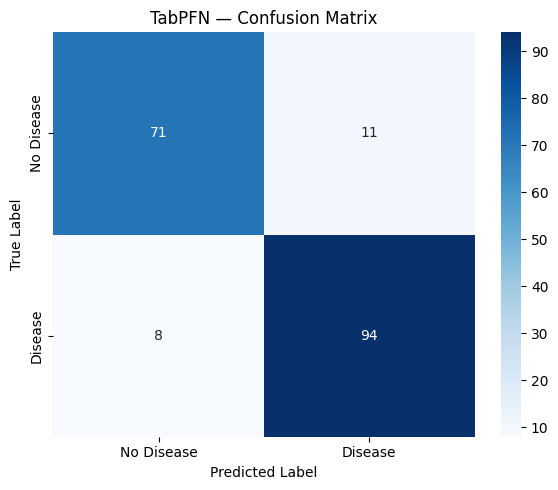

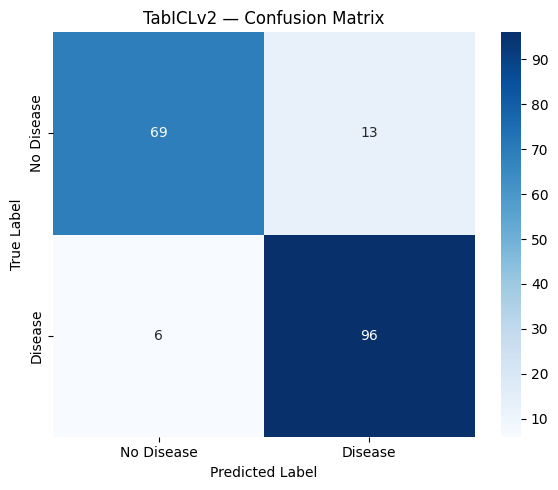

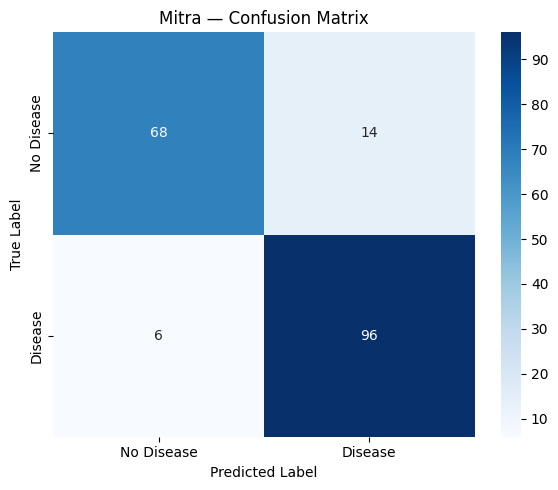

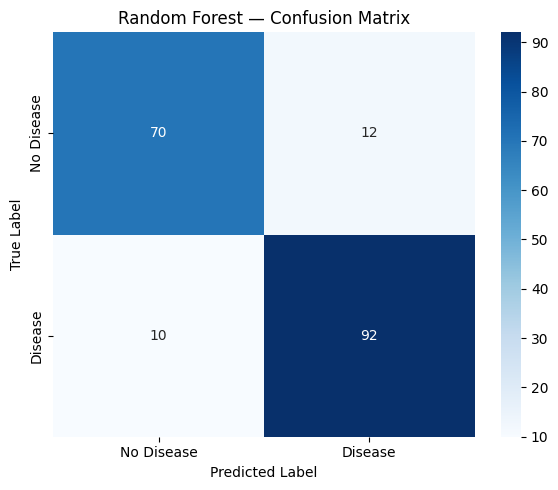

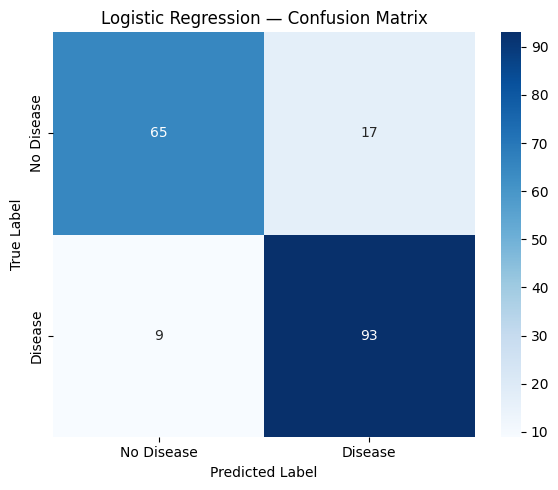

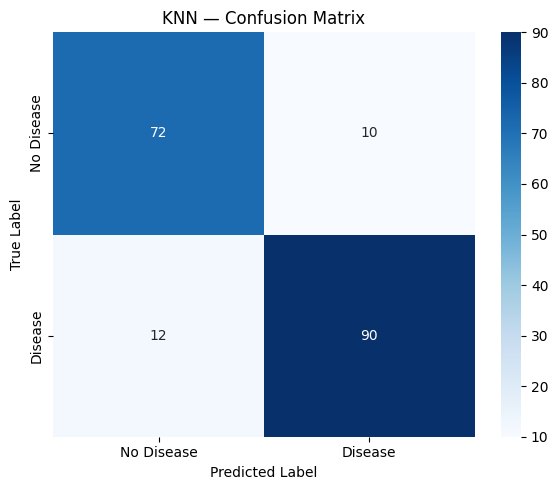

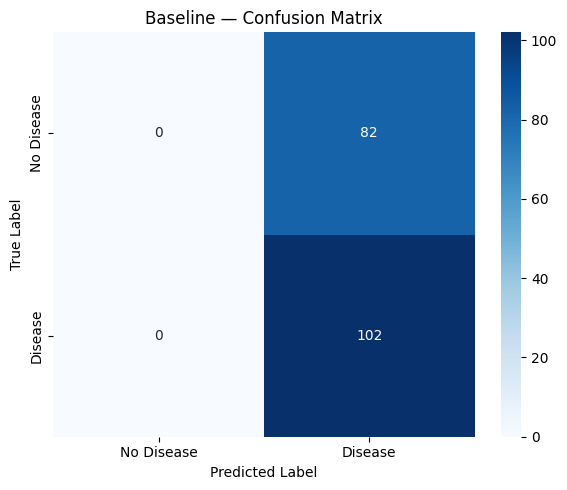

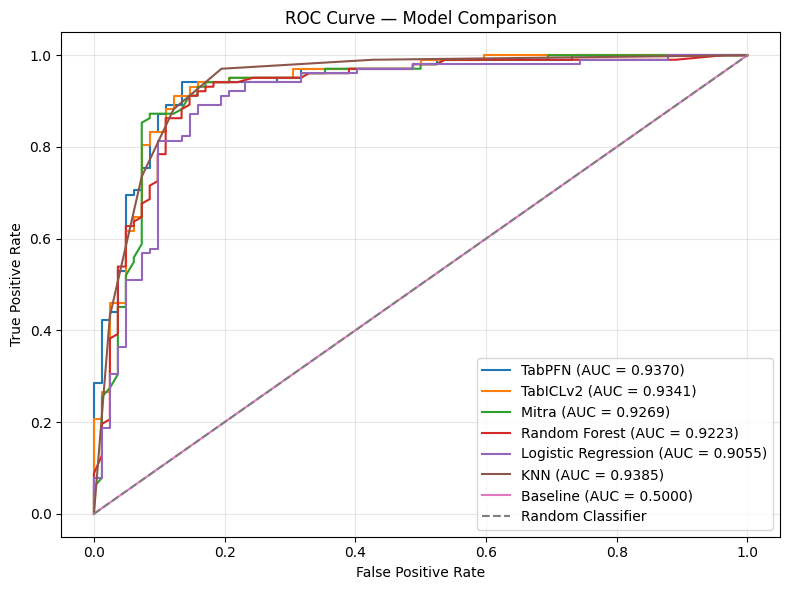

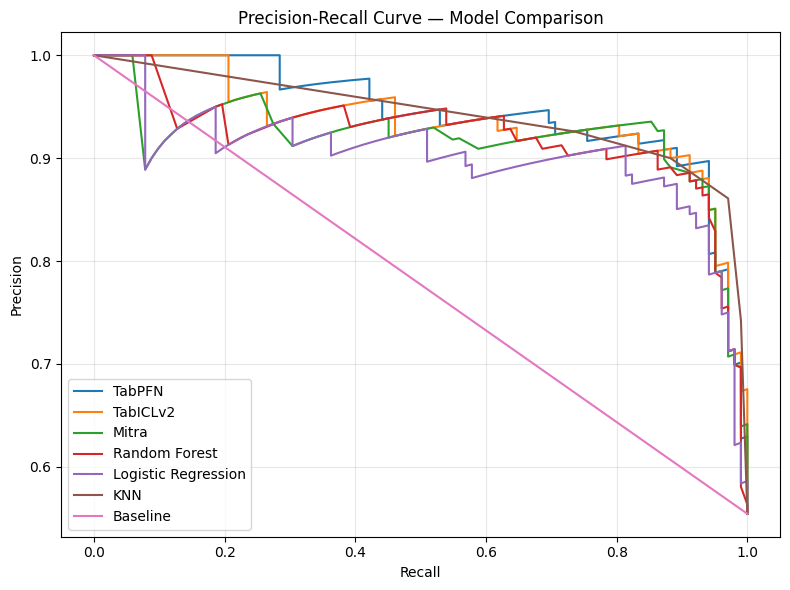

In [41]:
# ============================================================
# STEP 16 — CONFUSION MATRIX + ROC CURVE + PR CURVE
# ============================================================

from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    auc,
    precision_recall_curve
)

# ============================================================
# 1. CONFUSION MATRIX — ALL MODELS
# ============================================================

model_predictions = {
    "TabPFN": y_pred_tabpfn,
    "TabICLv2": y_pred_tabicl,
    "Mitra": y_pred_mitra,
    "Random Forest": y_pred_rf,
    "Logistic Regression": y_pred_lr,
    "KNN": y_pred_knn,
    "Baseline": y_pred_baseline
}

for model_name, y_pred in model_predictions.items():

    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(6, 5))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["No Disease", "Disease"],
        yticklabels=["No Disease", "Disease"]
    )

    plt.title(f"{model_name} — Confusion Matrix")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.tight_layout()
    plt.show()


# ============================================================
# 2. ROC CURVE — ALL MODELS
# ============================================================

model_probabilities = {
    "TabPFN": y_prob_tabpfn,
    "TabICLv2": y_prob_tabicl,
    "Mitra": y_prob_mitra,
    "Random Forest": y_prob_rf,
    "Logistic Regression": y_prob_lr,
    "KNN": y_prob_knn,
    "Baseline": y_prob_baseline
}

plt.figure(figsize=(8, 6))

for model_name, y_prob in model_probabilities.items():

    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc_value = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        label=f"{model_name} (AUC = {roc_auc_value:.4f})"
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.title("ROC Curve — Model Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# ============================================================
# 3. PRECISION-RECALL CURVE — ALL MODELS
# ============================================================

plt.figure(figsize=(8, 6))

for model_name, y_prob in model_probabilities.items():

    precision, recall, _ = precision_recall_curve(
        y_test,
        y_prob
    )

    plt.plot(
        recall,
        precision,
        label=model_name
    )

plt.title("Precision-Recall Curve — Model Comparison")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [42]:
# ============================================================
# STEP 17 — MODEL COMPARISON TABLE
# ============================================================

comparison_table = final_test_results.copy()

comparison_table["CV ROC-AUC"] = comparison_table["Model"].map(
    cv_results.set_index("Model")["ROC-AUC"]
)

comparison_table["CV F1-Score"] = comparison_table["Model"].map(
    cv_results.set_index("Model")["F1-Score"]
)

comparison_table = comparison_table[
    [
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score",
        "ROC-AUC",
        "CV F1-Score",
        "CV ROC-AUC"
    ]
]

comparison_table = comparison_table.round(4)

print("=" * 80)
print("MODEL COMPARISON — CROSS-VALIDATION vs FINAL TEST")
print("=" * 80)

display(comparison_table)

print("\nBest model according to 5-fold CV ROC-AUC:")
print(
    cv_results.iloc[0]["Model"],
    "→",
    cv_results.iloc[0]["ROC-AUC"]
)

print("\nBest model according to 5-fold CV F1-Score:")
best_f1_model = cv_results.sort_values(
    by="F1-Score",
    ascending=False
).iloc[0]

print(
    best_f1_model["Model"],
    "→",
    best_f1_model["F1-Score"]
)

MODEL COMPARISON — CROSS-VALIDATION vs FINAL TEST


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC,CV F1-Score,CV ROC-AUC
0,KNN,0.8804,0.9000,0.8824,0.8911,0.9385,0.8614,0.8957
1,TabPFN,0.8967,0.8952,0.9216,0.9082,0.9370,0.8837,0.9419
2,TabICLv2,0.8967,0.8807,0.9412,0.9100,0.9341,0.8837,0.9397
3,Mitra,0.8913,0.8727,0.9412,0.9057,0.9269,0.8790,0.9340
4,Random Forest,0.8804,0.8846,0.9020,0.8932,0.9223,0.8745,0.9261
5,Logistic Regression,0.8587,0.8455,0.9118,0.8774,0.9055,0.8547,0.9090
6,Baseline,0.5543,0.5543,1.0000,0.7133,0.5000,0.7123,0.5000



Best model according to 5-fold CV ROC-AUC:
TabPFN → 0.9419

Best model according to 5-fold CV F1-Score:
TabPFN → 0.8837


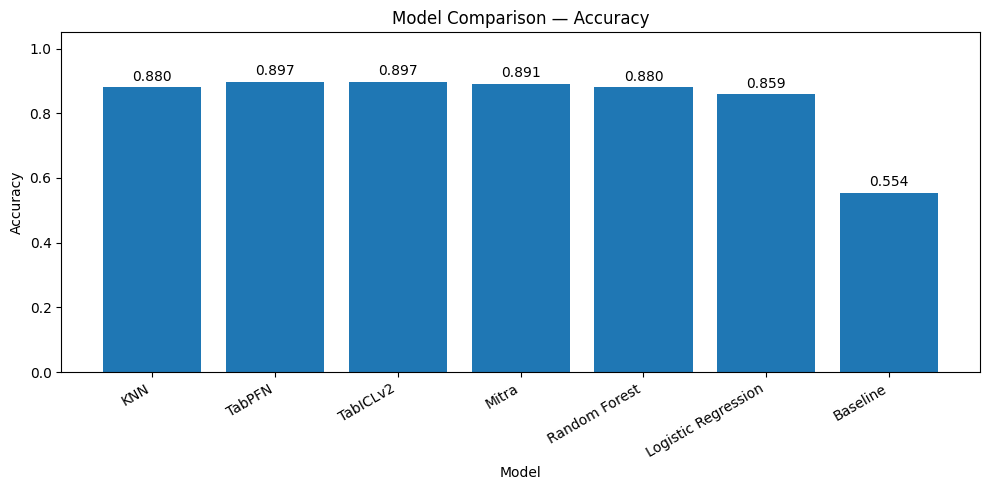

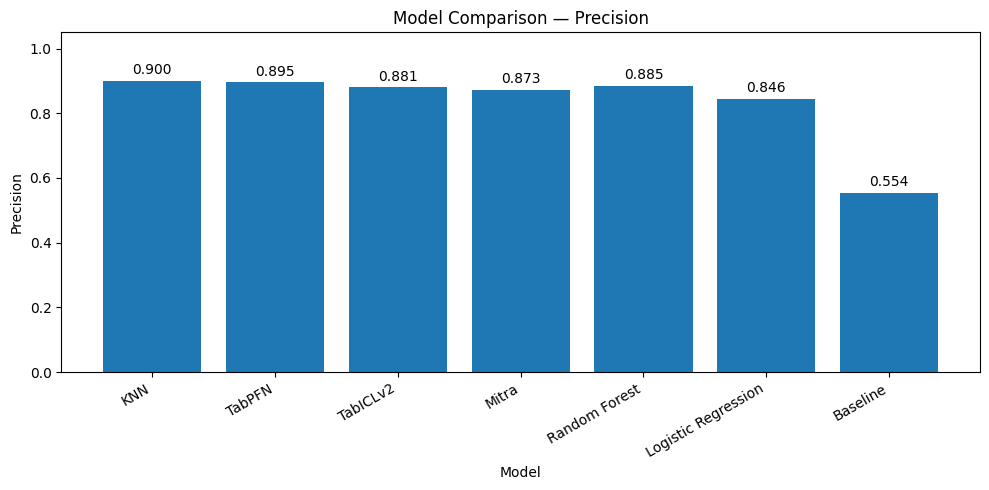

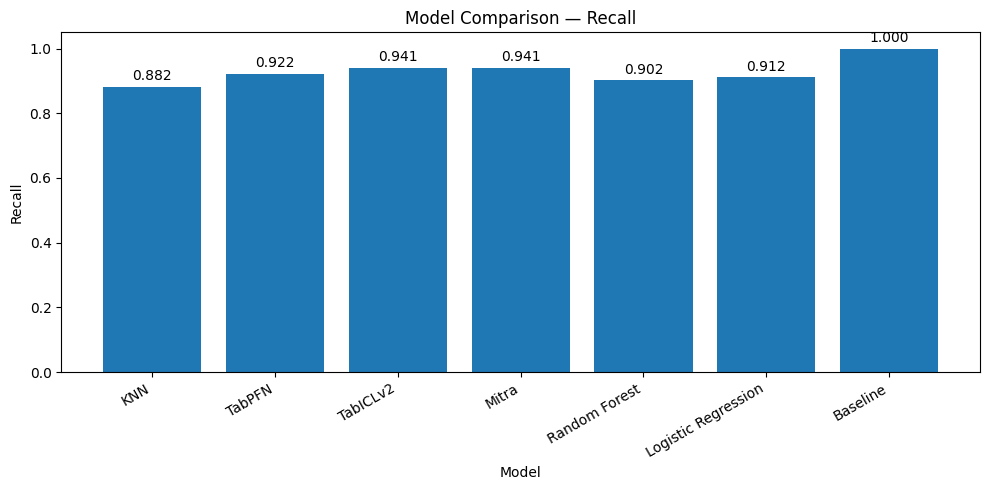

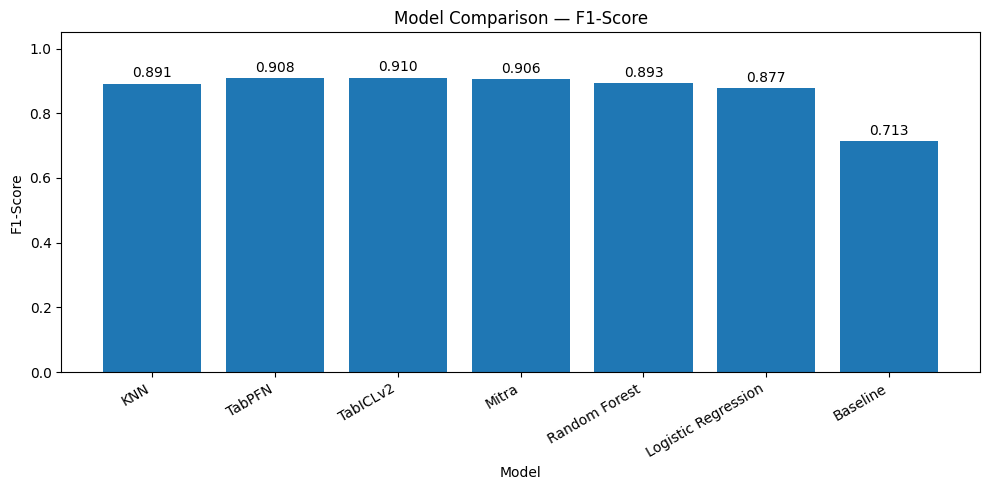

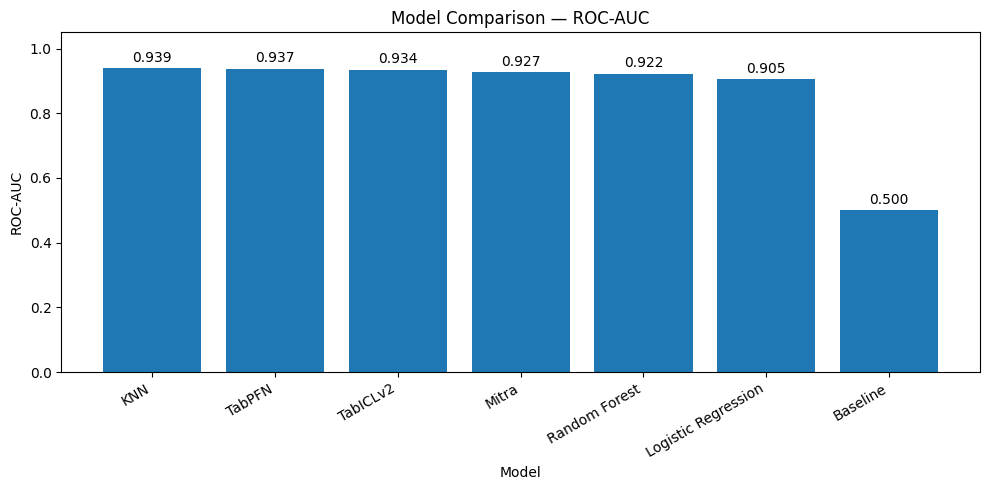

In [43]:
# ============================================================
# STEP 18 — MODEL COMPARISON VISUALIZATION
# ============================================================

plot_data = final_test_results.copy()

metrics = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1-Score",
    "ROC-AUC"
]

for metric in metrics:
    plt.figure(figsize=(10, 5))

    plt.bar(
        plot_data["Model"],
        plot_data[metric]
    )

    plt.title(f"Model Comparison — {metric}")
    plt.xlabel("Model")
    plt.ylabel(metric)
    plt.ylim(0, 1.05)
    plt.xticks(rotation=30, ha="right")

    for i, value in enumerate(plot_data[metric]):
        plt.text(
            i,
            value + 0.02,
            f"{value:.3f}",
            ha="center"
        )

    plt.tight_layout()
    plt.show()

In [44]:
# ============================================================
# STEP 19 — ERROR ANALYSIS
# ============================================================

# Use the CV-selected best model: TabPFN
best_model_name = "TabPFN"

y_pred_best = y_pred_tabpfn
y_prob_best = y_prob_tabpfn

# Identify incorrect predictions
error_analysis = X_test.copy()
error_analysis["Actual"] = y_test.values
error_analysis["Predicted"] = y_pred_best
error_analysis["Prediction_Probability"] = y_prob_best

error_analysis["Error"] = (
    error_analysis["Actual"] != error_analysis["Predicted"]
)

errors_only = error_analysis[
    error_analysis["Error"] == True
].copy()

print("=" * 80)
print("ERROR ANALYSIS — TABPFN")
print("=" * 80)

print("Total Test Samples :", len(error_analysis))
print("Correct Predictions:", (~error_analysis["Error"]).sum())
print("Incorrect Predictions:", error_analysis["Error"].sum())
print(
    "Error Rate:",
    round(error_analysis["Error"].mean(), 4)
)

print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred_best)

cm_df = pd.DataFrame(
    cm,
    index=["Actual 0", "Actual 1"],
    columns=["Predicted 0", "Predicted 1"]
)

display(cm_df)

print("\nMisclassified Samples:")
display(errors_only)

print("\nFalse Positives:",
      ((y_test == 0) & (y_pred_best == 1)).sum())

print("False Negatives:",
      ((y_test == 1) & (y_pred_best == 0)).sum())

ERROR ANALYSIS — TABPFN
Total Test Samples : 184
Correct Predictions: 165
Incorrect Predictions: 19
Error Rate: 0.1033

Confusion Matrix:


,Predicted 0,Predicted 1
Actual 0,71,11
Actual 1,8,94



Misclassified Samples:


,age,sex,chest pain type,resting bp s,cholesterol,fasting blood sugar,resting ecg,max heart rate,exercise angina,oldpeak,ST slope,Actual,Predicted,Prediction_Probability,Error
765,58,1,3,132.0,224.0,0,2,173,0,3.2,1,1,0,0.181966,True
1,49,0,3,160.0,180.0,0,0,156,0,1.0,2,1,0,0.171173,True
842,41,1,2,135.0,203.0,0,0,132,0,0.0,2,0,1,0.829302,True
315,53,1,4,80.0,237.0,0,0,141,1,2.0,3,0,1,0.952480,True
748,66,1,4,112.0,212.0,0,2,132,1,0.1,1,1,0,0.487381,True
607,51,0,4,114.0,258.0,1,2,96,0,1.0,1,0,1,0.776869,True
308,53,1,2,130.0,237.0,0,1,120,0,0.7,3,0,1,0.566863,True
435,63,1,4,126.0,237.0,0,1,120,0,1.5,3,0,1,0.906141,True
1184,57,0,4,140.0,241.0,0,0,123,1,0.2,2,1,0,0.460482,True
1161,59,1,1,134.0,204.0,0,0,162,0,0.8,1,1,0,0.087977,True



False Positives: 11
False Negatives: 8


In [45]:
# ============================================================
# STEP 20 — INTERPRETATION & LIMITATIONS
# ============================================================

print("=" * 80)
print("INTERPRETATION & LIMITATIONS")
print("=" * 80)

best_cv_model = cv_results.iloc[0]["Model"]
best_cv_auc = cv_results.iloc[0]["ROC-AUC"]

print(f"""
BEST MODEL:
Based on 5-fold cross-validation ROC-AUC, {best_cv_model} achieved
the highest validation performance with a ROC-AUC of {best_cv_auc:.4f}.

INTERPRETATION:
The evaluated models were able to learn meaningful patterns from
the clinical and physiological features used in the dataset.
TabPFN achieved the strongest overall cross-validation ROC-AUC,
indicating good discrimination between the two target classes.

ERROR ANALYSIS:
The selected TabPFN model produced 19 incorrect predictions on the
184-sample test set, including 11 false positives and 8 false negatives.

LIMITATIONS:
1. The dataset is relatively small.
2. The dataset may not represent all patient populations.
3. Duplicate records were present in the original dataset.
4. Some zero values required careful interpretation during data cleaning.
5. Model predictions should not be treated as a medical diagnosis.
6. External clinical validation would be required before real-world use.
""")

INTERPRETATION & LIMITATIONS

BEST MODEL:
Based on 5-fold cross-validation ROC-AUC, TabPFN achieved
the highest validation performance with a ROC-AUC of 0.9419.

INTERPRETATION:
The evaluated models were able to learn meaningful patterns from
the clinical and physiological features used in the dataset.
TabPFN achieved the strongest overall cross-validation ROC-AUC,
indicating good discrimination between the two target classes.

ERROR ANALYSIS:
The selected TabPFN model produced 19 incorrect predictions on the
184-sample test set, including 11 false positives and 8 false negatives.

LIMITATIONS:
1. The dataset is relatively small.
2. The dataset may not represent all patient populations.
3. Duplicate records were present in the original dataset.
4. Some zero values required careful interpretation during data cleaning.
5. Model predictions should not be treated as a medical diagnosis.
6. External clinical validation would be required before real-world use.



In [46]:
# ============================================================
# STEP 21 — REPRODUCIBILITY & COMPUTATIONAL INFORMATION
# ============================================================

import sys
import sklearn
import numpy
import pandas
import matplotlib
import seaborn

print("=" * 80)
print("REPRODUCIBILITY INFORMATION")
print("=" * 80)

print("Python Version       :", sys.version.split()[0])
print("NumPy Version        :", numpy.__version__)
print("Pandas Version       :", pandas.__version__)
print("Scikit-learn Version :", sklearn.__version__)
print("Matplotlib Version   :", matplotlib.__version__)
print("Seaborn Version      :", seaborn.__version__)

print("\nRandom State:", RANDOM_STATE)

print("\nDataset Information:")
print("Dataset Shape        :", df.shape)
print("Training Samples     :", X_train.shape[0])
print("Testing Samples      :", X_test.shape[0])
print("Number of Features   :", X_train.shape[1])

print("\nCross-Validation:")
print("Strategy             : StratifiedKFold")
print("Number of Folds      : 5")
print("Shuffle              : True")
print("Random State         :", RANDOM_STATE)

print("\nSelected Model:")
print("Model                :", best_cv_model)
print("Selection Metric     : CV ROC-AUC")
print("CV ROC-AUC           :", best_cv_auc)

REPRODUCIBILITY INFORMATION
Python Version       : 3.13.15
NumPy Version        : 2.1.3
Pandas Version       : 2.2.3
Scikit-learn Version : 1.6.1
Matplotlib Version   : 3.10.0
Seaborn Version      : 0.13.2

Random State: 42

Dataset Information:
Dataset Shape        : (918, 12)
Training Samples     : 734
Testing Samples      : 184
Number of Features   : 11

Cross-Validation:
Strategy             : StratifiedKFold
Number of Folds      : 5
Shuffle              : True
Random State         : 42

Selected Model:
Model                : TabPFN
Selection Metric     : CV ROC-AUC
CV ROC-AUC           : 0.9419


In [47]:
# ============================================================
# STEP 22 — CONCLUSION
# ============================================================

print("=" * 80)
print("PROJECT CONCLUSION")
print("=" * 80)

print(f"""
This project developed a reproducible machine learning pipeline
for heart disease prediction using clinical and physiological
features.

Seven approaches were evaluated:
1. Baseline
2. Logistic Regression
3. Random Forest
4. KNN
5. TabPFN
6. TabICLv2
7. Mitra

Using 5-fold stratified cross-validation, TabPFN achieved the
highest ROC-AUC of 0.9419 and was selected as the final model.

On the unseen test set, TabPFN achieved:
- Accuracy : 0.8967
- Precision: 0.8952
- Recall   : 0.9216
- F1-Score : 0.9082
- ROC-AUC  : 0.9370

The results show that the evaluated machine learning models can
effectively identify patterns associated with heart disease.
However, the model should be considered a decision-support tool
rather than a replacement for professional medical diagnosis.
""")

PROJECT CONCLUSION

This project developed a reproducible machine learning pipeline
for heart disease prediction using clinical and physiological
features.

Seven approaches were evaluated:
1. Baseline
2. Logistic Regression
3. Random Forest
4. KNN
5. TabPFN
6. TabICLv2
7. Mitra

Using 5-fold stratified cross-validation, TabPFN achieved the
highest ROC-AUC of 0.9419 and was selected as the final model.

On the unseen test set, TabPFN achieved:
- Accuracy : 0.8967
- Precision: 0.8952
- Recall   : 0.9216
- F1-Score : 0.9082
- ROC-AUC  : 0.9370

The results show that the evaluated machine learning models can
effectively identify patterns associated with heart disease.
However, the model should be considered a decision-support tool
rather than a replacement for professional medical diagnosis.



In [48]:
# ============================================================
# STEP 23 — SAVE FINAL RESULTS
# ============================================================

# Save model comparison results
comparison_table.to_csv(
    "heart_disease_model_comparison.csv",
    index=False
)

# Save CV results
cv_results.to_csv(
    "heart_disease_cv_results.csv",
    index=False
)

# Save final test results
final_test_results.to_csv(
    "heart_disease_final_test_results.csv",
    index=False
)

# Save TabPFN error analysis
errors_only.to_csv(
    "heart_disease_tabpfn_errors.csv",
    index=False
)

print("=" * 80)
print("FINAL RESULTS SAVED SUCCESSFULLY")
print("=" * 80)

print("1. heart_disease_model_comparison.csv")
print("2. heart_disease_cv_results.csv")
print("3. heart_disease_final_test_results.csv")
print("4. heart_disease_tabpfn_errors.csv")

FINAL RESULTS SAVED SUCCESSFULLY
1. heart_disease_model_comparison.csv
2. heart_disease_cv_results.csv
3. heart_disease_final_test_results.csv
4. heart_disease_tabpfn_errors.csv


In [49]:
# ============================================================
# STEP 24 — FINAL PROJECT SUMMARY
# ============================================================

print("=" * 80)
print("FINAL PROJECT SUMMARY")
print("=" * 80)

print("Project :", PROJECT_TITLE)
print("Dataset :", DATASET_NAME)
print("Samples :", df.shape[0])
print("Features:", df.shape[1] - 1)

print("\nModels Evaluated:")
for model in final_test_results["Model"]:
    print("-", model)

print("\nSelected Final Model:")
print("Model    :", best_cv_model)
print("CV AUC   :", best_cv_auc)

best_test = final_test_results[
    final_test_results["Model"] == best_cv_model
].iloc[0]

print("\nFinal Test Performance:")
print("Accuracy :", best_test["Accuracy"])
print("Precision:", best_test["Precision"])
print("Recall   :", best_test["Recall"])
print("F1-Score :", best_test["F1-Score"])
print("ROC-AUC  :", best_test["ROC-AUC"])

print("\nPipeline completed successfully.")

FINAL PROJECT SUMMARY
Project : Heart Disease Prediction using Machine Learning
Dataset : Heart Disease Dataset
Samples : 918
Features: 11

Models Evaluated:
- KNN
- TabPFN
- TabICLv2
- Mitra
- Random Forest
- Logistic Regression
- Baseline

Selected Final Model:
Model    : TabPFN
CV AUC   : 0.9419

Final Test Performance:
Accuracy : 0.8967
Precision: 0.8952
Recall   : 0.9216
F1-Score : 0.9082
ROC-AUC  : 0.937

Pipeline completed successfully.
